In [2]:
import pandas as pd
import matplotlib.pyplot as plt
# from scipy.signal import find_peaks
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import t
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
from scipy.optimize import minimize

In [3]:

# 50 days dataset
file_path = "csv-files/zro2_white&green_ 50_days.csv"
data = pd.read_csv(file_path, header=None)
spectrum_50 = data[0].values
t_50 = 4279386 # 50 days exposure
a_50 = 0.357304
b_50 = -0.295444
c_50  = 1.352297E-009
E_kev =  np.arange(len(spectrum_50)) * a_50 + b_50 + c_50 * np.arange(len(spectrum_50))**2
mask = (E_kev>=50) & (E_kev <= 3000)
E_kev = E_kev[mask]
spectrum_50 = spectrum_50[mask]



file_path = "csv-files/bkg.csv"
data = pd.read_csv(file_path, header=None)
spectrum_bkg = data[0].values
t_bkg = 4143234 # 40 days exposure
spectrum_bkg = spectrum_bkg[mask]
spectrum_bkg_50 = spectrum_bkg * (t_50 / t_bkg)



spec_net = spectrum_50 -spectrum_bkg_50

In [4]:
# definition for the withe and green sample
mw = 0.3229
tw = 1145735
mg = 0.2275
tg = 601555

mtot = mw+mg


In [5]:
E_kev
spectrum_w = spec_net * (mw/mtot) * (tw/t_50)
spectrum_g = spec_net * (mg/mtot) * (tg/t_50)

C:\Users\rirri\AppData\Local\Temp\ipykernel_38824\2948812047.py:36: RuntimeWarning: invalid value encountered in sqrt
  N_50, err_50 = counts, np.sqrt(counts)


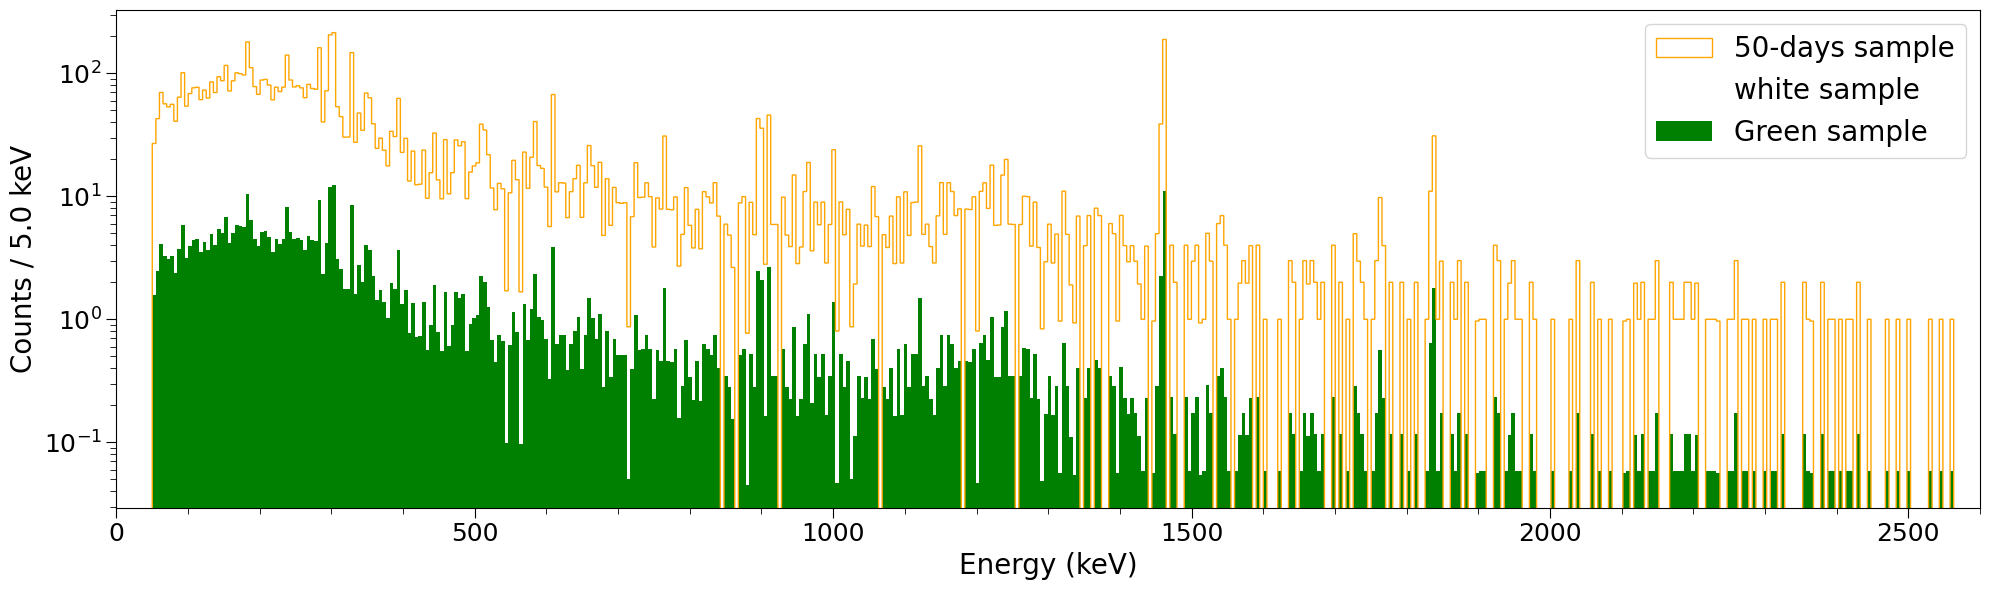

In [6]:
style = 'dark_background'
#plt.style.use(style)  

plt.figure(figsize=(20, 6))
ax = plt.gca()


dx_major = 500
dx_minor = 100

ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 5
dy_minor = 1

ax.yaxis.set_major_locator(MultipleLocator(dy_major))
ax.yaxis.set_minor_locator(MultipleLocator(dy_minor))

ax.tick_params(axis='x', which='major', length=7, labelsize=18)
ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=18)
ax.tick_params(axis='y', which='minor', length=4)

# Bin width


bins = np.linspace(min(E_kev), max(E_kev), int(len(E_kev)/14))

counts, bin_edge, _ = plt.hist(E_kev, bins = bins, weights = spec_net,  histtype='step', color = 'orange', 
                               label='50-days sample')

counts, bin_edge, _ = plt.hist(E_kev, bins = bins, weights = spectrum_w, color = "white" , label='white sample')
db = bin_edge[1]- bin_edge[0]
E_bin = 0.5 * (bin_edge[1:] + bin_edge[:-1])
N_50, err_50 = counts, np.sqrt(counts)

counts, bin_edge, _ = plt.hist(E_kev, bins = bins, weights = spectrum_g,  color = 'green', 
                               label='Green sample')



plt.xlabel('Energy (keV)', size = 20)
plt.ylabel(rf'Counts / {db:.1f} keV', size = 20)
plt.xlim(0, 2600)
plt.yscale("log")
#plt.grid(alpha=0.15)
#ax.grid(which='major', linestyle='-', alpha=0.15)
#ax.grid(which='minor', linestyle='--', alpha=0.15)
plt.tight_layout()
plt.legend(fontsize = 20)
plt.show()

In [7]:
def fit_gaussian_poisson_plot(E, N, center, de):
    """
    Fit gaussiana + fondo su Poisson usando i centri dei bin.
    Produce:
      1) Istogramma + fit
      2) Profile likelihood ΔNLL per tutti i parametri con ±1σ interpolati
    Restituisce: fit_values, err_minus_all, err_plus_all, result
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.optimize import minimize

    # ==========================
    # Bin identici al plot originale
    # ==========================
    bins = np.linspace(min(E), max(E), int(len(E))+1)
    db = bins[1]-bins[0]
    counts, edges = np.histogram(E, bins=bins, weights=N)
    bin_centers = 0.5*(edges[:-1]+edges[1:])
    #print(len(E), len(bin_centers), len(N))

    # ==========================
    # ROI
    # ==========================
    roi = (center-de, center+de)
    """
    mask = (bin_centers >= roi[0]) & (bin_centers <= roi[1])
    counts_roi = counts[mask]
    centers_roi = bin_centers[mask]"""
    mask = (E >= roi[0]) & (E <= roi[1])
    counts_roi = N[mask]
    centers_roi = E[mask]

    # ==========================
    # Modello classico sui centri
    # ==========================
    def model(params, x):
        A, mu, sigma, B = params
        return A * (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2*sigma**2)) + B

    # ==========================
    # NLL Poisson
    # ==========================
    def nll(params):
        lam = model(params, centers_roi)
        lam = np.clip(lam, 1e-12, None)
        return np.sum(lam - counts_roi*np.log(lam))

    # ==========================
    # Stime iniziali
    # ==========================
    A0 = np.sum(counts_roi)
    print(A0)
    mu0 = centers_roi[np.argmax(counts_roi)]
    sigma0 = 1.0
    M0 = 0.0
    B0 = np.min(counts_roi)
    initial = [A0, mu0, sigma0,  B0]
    bounds = [(0,None),(roi[0],roi[1]),(1e-5,100),(1e-7,None)]

    result = minimize(nll, initial, bounds=bounds, method="L-BFGS-B")
    fit_values = result.x
    param_names = ['A','mu','sigma','B']

    print("\nBest fit:")
    for n,v in zip(param_names, fit_values):
        print(f"{n} = {v:.3f}")

    # ==========================
    # PLOT ISTOGRAMMA + FIT
    # ==========================
    fig, ax = plt.subplots(figsize=(5,4))
    plt.hist(E, bins=bins, weights=N, color='tab:gray', histtype='step', label='50-days exposure')
    x_plot = np.linspace(roi[0], roi[1], 1000)
    y_plot = model(fit_values, x_plot)
    plt.scatter(centers_roi, counts_roi, color = 'black')
    plt.plot(x_plot, y_plot, color='deepskyblue', lw=2, label='Fit')
    plt.axvline(fit_values[1], color='deepskyblue', ls='--', label=f'μ = {fit_values[1]:.3f}')
    plt.xlim(roi)
    plt.hlines(fit_values[-1], min(roi), max(roi))
    plt.ylim(0, max(counts_roi)*1.5)
    plt.xlabel("Energy (keV)", size=13)
    plt.ylabel(f"Counts / {db:.1f} keV", size=13)
    plt.grid(alpha=0.13)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==========================
    # PROFILE LIKELIHOOD ΔNLL
    # ==========================
    scans, delta_nlls, err_minus_all, err_plus_all = [], [], [], []
    nll_min = nll(fit_values)

    for i, pname in enumerate(param_names):
        val_fit = fit_values[i]
        # definizione range scan
        if pname=='A':
            scan = np.linspace(val_fit*0.01, val_fit*2, 50)
        elif pname=='mu':
            scan = np.linspace(max(roi[0], val_fit-3), min(roi[1], val_fit+3), 50)
        elif pname=='sigma':
            scan = np.linspace(val_fit*0.2, val_fit*2, 50)
        else:
            scan = np.linspace(0, val_fit*3 if val_fit>0 else 1, 50)

        delta_nll = []
        for x_val in scan:
            def nll_profile(other_params):
                full = fit_values.copy()
                cnt = 0
                for j in range(4):
                    if j==i:
                        full[j] = x_val
                    else:
                        full[j] = other_params[cnt]
                        cnt +=1
                return nll(full)
            other_initial = [fit_values[j] for j in range(4) if j!=i]
            other_bounds  = [bounds[j] for j in range(4) if j!=i]
            res2 = minimize(nll_profile, other_initial, bounds=other_bounds, method="L-BFGS-B")
            delta_nll.append(res2.fun - nll_min)

        delta_nll = np.array(delta_nll)
        scans.append(scan)
        delta_nlls.append(delta_nll)

        # ==========================
        # errore ±1σ con np.interp (robusto)
        # ==========================
        scan_left = scan[scan < val_fit]
        delta_left = delta_nll[scan < val_fit]
        if np.any(delta_left >= 0.5):
            # invertiamo per cercare da destra verso sinistra
            err_minus = val_fit - np.interp(0.5, delta_left[::-1], scan_left[::-1])
        else:
            err_minus = np.nan

        scan_right = scan[scan > val_fit]
        delta_right = delta_nll[scan > val_fit]
        if np.any(delta_right >= 0.5):
            err_plus = np.interp(0.5, delta_right, scan_right) - val_fit
        else:
            err_plus = np.nan

        err_minus_all.append(err_minus)
        err_plus_all.append(err_plus)

        print(f"{pname} = {val_fit:.3f} -{err_minus:.3f}/+{err_plus:.3f}")

    # ==========================
    # PLOT ΔNLL 2x2
    # ==========================
    fig, axes = plt.subplots(2, 2, figsize=(3,3))
    axes = axes.flatten()

    for i in range(len(param_names)):
        ax = axes[i]
        ax.plot(scans[i], delta_nlls[i], 'r-')
        ax.axhline(0.5, color='blue', linestyle='--')
        ax.axvline(fit_values[i], color='green', linestyle='--')
        ax.axvline(fit_values[i]-err_minus_all[i], color='orange', linestyle='--')
        ax.axvline(fit_values[i]+err_plus_all[i], color='purple', linestyle='--')
        ax.set_xlabel(param_names[i])
        ax.set_ylabel('ΔNLL')
        ax.grid(alpha=0.3)

    # disattiva subplot vuoto
    for j in range(len(param_names), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return fit_values, err_minus_all, err_plus_all, result

244.83115508320316

Best fit:
A = 38.399
mu = 329.378
sigma = 0.869
B = 2.534


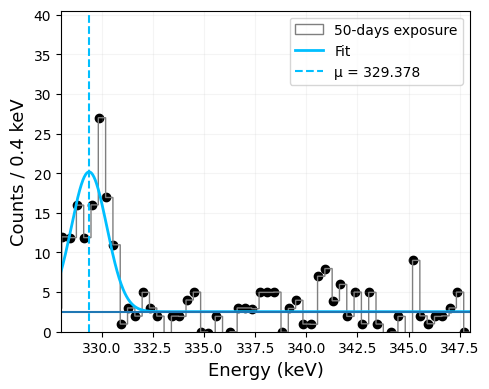

A = 38.399 -4.354/+4.770
mu = 329.378 -0.130/+0.107
sigma = 0.869 -0.098/+0.129
B = 2.534 -0.223/+0.237


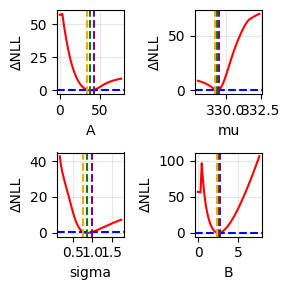

Picco 338 keV: sigma = 0.869 -0.098/+0.129


In [9]:
peak = 338 # 228Ac
fit_val, fit_err_minus, fit_err_plus, res = fit_gaussian_poisson_plot(
        E_kev, spec_net, center=peak, de=10 )
    
Nw, mu_fit, sigma_fit,  B_fit = fit_val
sigma_err_minus = fit_err_minus[2]
sigma_err_plus  = fit_err_plus[2]
    
    
print(f"Picco {peak} keV: sigma = {sigma_fit:.3f} -{sigma_err_minus:.3f}/+{sigma_err_plus:.3f}")

3.3279554959191207

Best fit:
A = 0.939
mu = 910.630
sigma = 1.427
B = 0.012


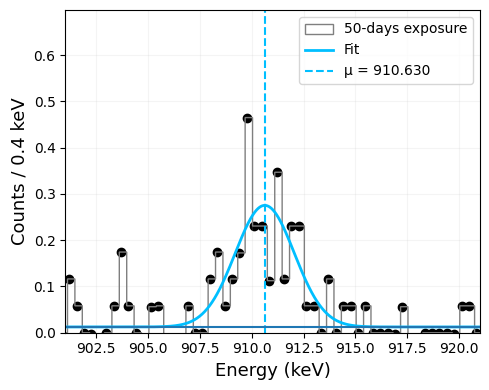

A = 0.939 -0.528/+0.750
mu = 910.630 -1.014/+1.195
sigma = 1.427 -0.634/+1.113
B = 0.012 -0.011/+nan


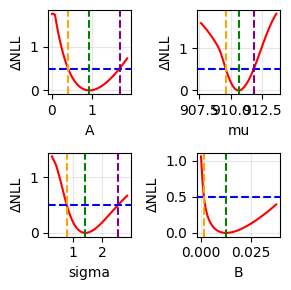

Picco 911 keV: sigma = 1.427 -1.113/+1.113


In [13]:
peak = 911 # 228Ac
fit_val, fit_err, fit_err, res = fit_gaussian_poisson_plot(
        E_kev, spectrum_g, center=peak, de=10 )
    
Ng, mu_fit, sigma_fit,  B_fit = fit_val
sigma_err_minus = fit_err[2]
sigma_err_plus  = fit_err[2]
    
    
print(f"Picco {peak} keV: sigma = {sigma_fit:.3f} -{sigma_err_minus:.3f}/+{sigma_err_plus:.3f}")

In [14]:
#A_fit, mu_fit, sigma_fit,  B_fit
errNw = 1.553
errNg = 0.704
Y = 0.258 #%%!
eff = 0.2255e-1   
eff_err = 0.19e-2
t_50
m = 0.2

In [15]:
mg

0.2275

In [16]:
def activity(N, t, Y, eff, m):
   A= N / (t * Y * eff * m)
   return A

def compute_A_error(N, sigma_N, t, Y, eff, sigma_eff, m):
    # Calculate A
    A = N / (t * Y * eff * m) * 1000 #mBq/kg
    
    # Relative uncertainty propagation (uncorrelated variables)
    sigma_A = A * np.sqrt(
        (sigma_N / N)**2 +
        (sigma_eff / eff)**2
    ) 
    
    return A, sigma_A

In [17]:
Aw, errAW = compute_A_error(Nw, errNw, tw, Y, eff, eff_err, mw)
Ag, errAg = compute_A_error(Ng, errNg, tg, Y, eff, eff_err, mg)

print(fr"White sample activity 228Ac {Aw:.4f} +/- {errAW:.2f}  mBq/kg")
print(f"Green sample activity 228Ac {Ag:.4f} +/- {errAg:.2f}mBq/kg")

White sample activity 228Ac 7.5121 +/- 0.96  mBq/kg
Green sample activity 228Ac 1.1799 +/- 0.89mBq/kg


In [18]:
Aw_mathias = 2 
Aw_err_math = 1
Ag_math = 5
Ag_err_math = 2

57.27705169440104

Best fit:
A = 16.169
mu = 910.630
sigma = 1.427
B = 0.215


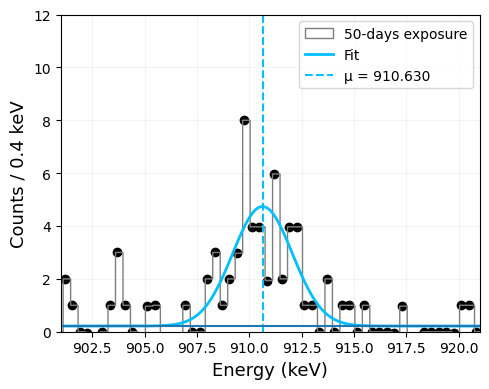

A = 16.169 -2.485/+2.714
mu = 910.630 -0.239/+0.255
sigma = 1.427 -0.175/+0.199
B = 0.215 -0.071/+0.090


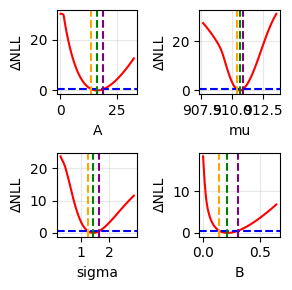

Picco 911 keV: sigma = 1.427 -0.175/+0.199


In [19]:
peak = 911 # 228Ac
fit_val, fit_err_minus, fit_err_plus, res = fit_gaussian_poisson_plot(
        E_kev, spec_net, center=peak, de=10 )
    
N50, mu_fit, sigma_fit,  B_fit = fit_val
sigma_err_minus = fit_err_minus[2]
sigma_err_plus  = fit_err_plus[2]
    
    
print(f"Picco {peak} keV: sigma = {sigma_fit:.3f} -{sigma_err_minus:.3f}/+{sigma_err_plus:.3f}")

In [20]:
m = mw + mg
print(m)

0.5504


In [21]:
A50, err50 = compute_A_error(N50, np.sqrt(N50) , t_50, Y, eff, eff_err, m)

print(fr"total sample activity 228Ac {A50:.4f} +/- {err50:.2f}  mBq/kg")

total sample activity 228Ac 1.1799 +/- 0.31  mBq/kg


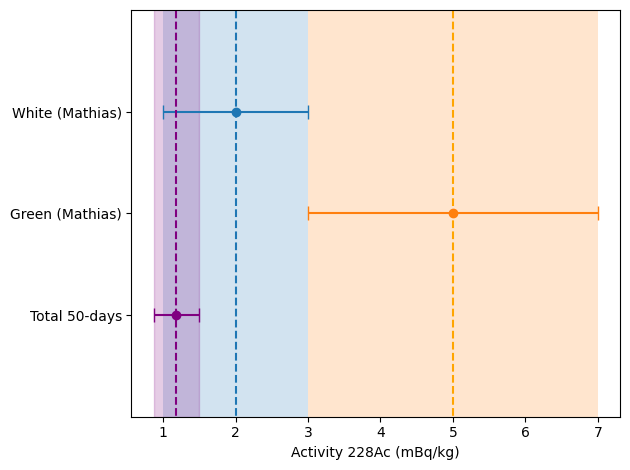

In [22]:
 
plt.figure()

# Bande  di Mathias (White)
plt.fill_betweenx(
    [-1, 3],
    Aw_mathias - Aw_err_math,
    Aw_mathias + Aw_err_math,
    alpha=0.2
)

# Bande ±σ di Mathias (Green)
plt.fill_betweenx(
    [-1, 3],
    Ag_math -  Ag_err_math,
    Ag_math +  Ag_err_math,
    alpha=0.2
)

# Punti Mathias (con errore)
plt.errorbar(Aw_mathias, 2, xerr=Aw_err_math, capsize=5, fmt='o')
plt.vlines(Aw_mathias, -2, 6, ls = '--')
plt.errorbar(Ag_math, 1, xerr=Ag_err_math,capsize=5, fmt='o')
plt.vlines(Ag_math, -2, 6, color= 'orange', ls = '--')
# Tuoi dati

plt.errorbar(A50, 0, xerr=err50, color = 'purple', capsize=5,fmt ='o')



# Bande  di 50 
plt.fill_betweenx(
    [-1, 5],
    A50 - err50,
    A50 + err50,
    color = "purple",
    alpha=0.2
)
plt.vlines(A50, -2, 6, color = 'purple', ls = '--')


plt.yticks(
    [0, 1, 2],
    ["Total 50-days","Green (Mathias)", "White (Mathias)"]
)

plt.xlabel("Activity 228Ac (mBq/kg)")

plt.ylim(-1, 3)
plt.tight_layout()
plt.show()

# Th-228 from Pb-212 & Bi-212 & Tl-208;

-----------

In [23]:
peaks = {
    "212-PB" : 238.6,
    "212_BI" : 727.33,
    "208-TL" : 2614

}

dx = {
    "212-PB" : 10,
    "212_BI" : 4,
    "208-TL" : 10
}

Y = {
     "212-PB" : 0.43,
    "212_BI" : 0.067,
    "208-TL" : 0.997
}

eff = { 
    "212-PB" : 0.035,
    "212_BI" : 0.0249 ,
    "208-TL" : 0.012}

eff_err = {
     "212-PB" : 0.23e-2,
    "212_BI" : 0.27e-2,
    "208-TL" : 0.28e-2
}


--- 212-PB ---
372.9065005741891

Best fit:
A = 17.759
mu = 238.425
sigma = 0.616
B = 5.772


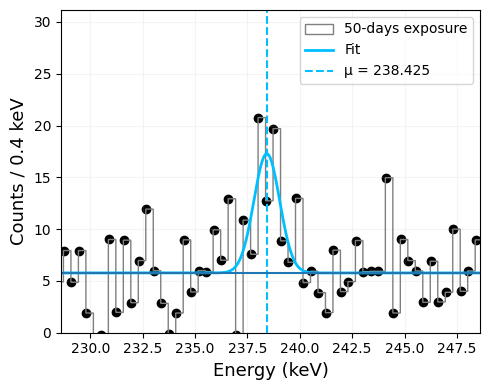

A = 17.759 -4.049/+4.658
mu = 238.425 -0.140/+0.170
sigma = 0.616 -0.169/+0.245
B = 5.772 -0.317/+0.337


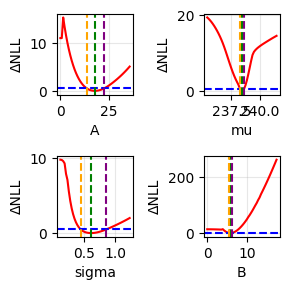


--- 212_BI ---
23.572803273964247

Best fit:
A = 4.922
mu = 726.930
sigma = 0.516
B = 0.445


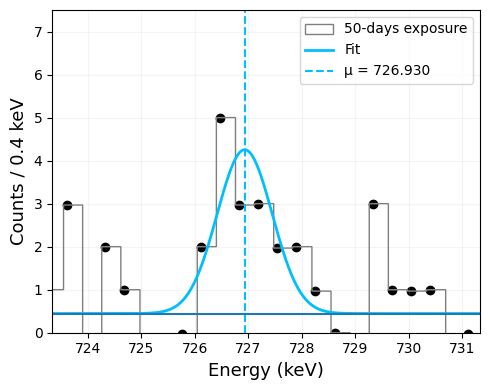

A = 4.922 -1.444/+1.651
mu = 726.930 -0.192/+0.183
sigma = 0.516 -0.114/+0.114
B = 0.445 -0.152/+0.197


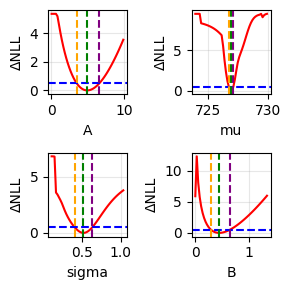


--- 208-TL ---
26.737109707054923

Best fit:
A = 9.554
mu = 2615.165
sigma = 1.924
B = 0.000


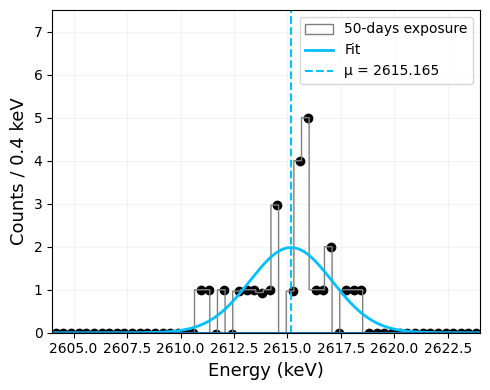

A = 9.554 -1.727/+1.961
mu = 2615.165 -0.371/+0.371
sigma = 1.924 -0.232/+0.297
B = 0.000 -nan/+nan


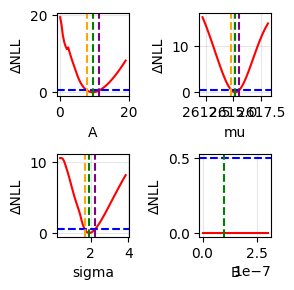

In [24]:
A_arr = []
A_err_arr = []

for label, peak in peaks.items():
    print(f"\n--- {label} ---")
    fit_val, fit_err_minus, fit_err_plus, res = fit_gaussian_poisson_plot(
        E_kev, spec_net, center=peak, de=dx[label] )
    
    N, mu_fit, sigma_fit,  B_fit = fit_val
    err_N = 0.5*(fit_err_minus[0]+ fit_err_plus[0])

    A, A_err = compute_A_error(N, err_N , t_50, Y[label], eff[label], eff_err[label], m)
    A_arr.append(A)
    A_err_arr.append(A_err)




In [25]:
for A, A_err in zip(A_arr, A_err_arr):
    print(fr"{A:.2f} +/- {A_err:.2f}  mBq/kg")

0.50 +/- 0.13  mBq/kg
1.25 +/- 0.42  mBq/kg
0.34 +/- 0.10  mBq/kg


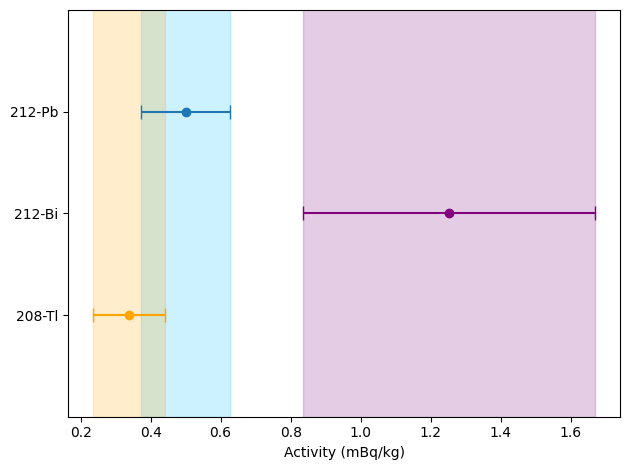

In [26]:
 
plt.figure()

plt.errorbar(A_arr[0], 2, xerr=A_err_arr[0], capsize=5,fmt='o')
plt.errorbar(A_arr[1], 1, xerr=A_err_arr[1], color = 'purple', capsize=5,fmt='o')
plt.errorbar(A_arr[2], 0, xerr=A_err_arr[2], capsize=5, color = 'orange', fmt ='o')

plt.fill_betweenx(
    [-1, 4],
    A_arr[0] - A_err_arr[0],
    A_arr[0] + A_err_arr[0],
    color = "deepskyblue",
    alpha=0.2
)

plt.fill_betweenx(
    [-1, 4],
    A_arr[1] - A_err_arr[1],
    A_arr[1] + A_err_arr[1],
    color = "purple",
    alpha=0.2
)

plt.fill_betweenx(
    [-1, 4],
    A_arr[2] - A_err_arr[2],
    A_arr[2] + A_err_arr[2],
    color = "orange",
    alpha=0.2
)

plt.yticks(
    [0, 1, 2],
    ["208-Tl","212-Bi", "212-Pb"]
)

plt.xlabel("Activity (mBq/kg)")

plt.ylim(-1, 3)
plt.tight_layout()
plt.show()

In [27]:
A_228Th = A_arr[1]
A_228Th_err = A_err_arr[1]

print(f"228Th activity : {A_228Th:.2f}  +/- {A_228Th_err : .2f} mBq/kg")

228Th activity : 1.25  +/-  0.42 mBq/kg


In [28]:
Aw_mathias = 1.4
Aw_err_math = 0.7
Ag_math = 4
Ag_err_math = 1

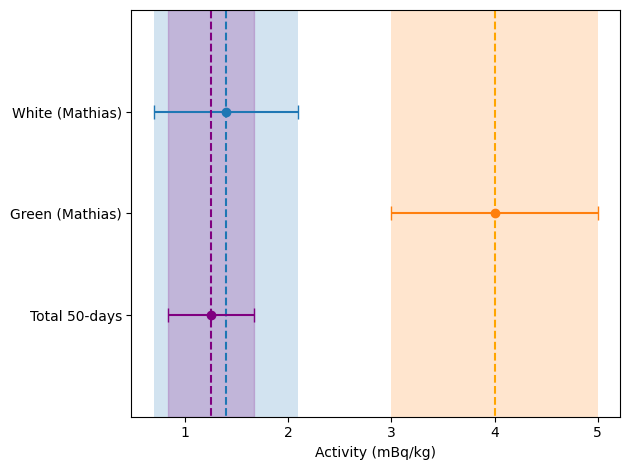

In [29]:
 
plt.figure()

# Bande  di Mathias (White)
plt.fill_betweenx(
    [-1, 3],
    Aw_mathias - Aw_err_math,
    Aw_mathias + Aw_err_math,
    alpha=0.2
)

# Bande ±σ di Mathias (Green)
plt.fill_betweenx(
    [-1, 3],
    Ag_math -  Ag_err_math,
    Ag_math +  Ag_err_math,
    alpha=0.2
)

# Punti Mathias (con errore)
plt.errorbar(Aw_mathias, 2, xerr=Aw_err_math, capsize=5, fmt='o')
plt.vlines(Aw_mathias, -2, 6, ls = '--')
plt.errorbar(Ag_math, 1, xerr=Ag_err_math,capsize=5, fmt='o')
plt.vlines(Ag_math, -2, 6, color= 'orange', ls = '--')
# Tuoi dati

plt.errorbar(A_228Th, 0, xerr=A_228Th_err, color = 'purple', capsize=5,fmt='o')


# Bande  di 50 
plt.fill_betweenx(
    [-1, 3],
    A_228Th - A_228Th_err,
    A_228Th + A_228Th_err,
    color = "purple",
    alpha=0.2
)
plt.vlines(A_228Th, -2, 6, color = 'purple', ls = '--')


plt.yticks(
    [0, 1, 2, ],
    ["Total 50-days", "Green (Mathias)", "White (Mathias)"]
)

plt.xlabel("Activity (mBq/kg)")

plt.ylim(-1, 3)
plt.tight_layout()
plt.show()

-----------

## 40K

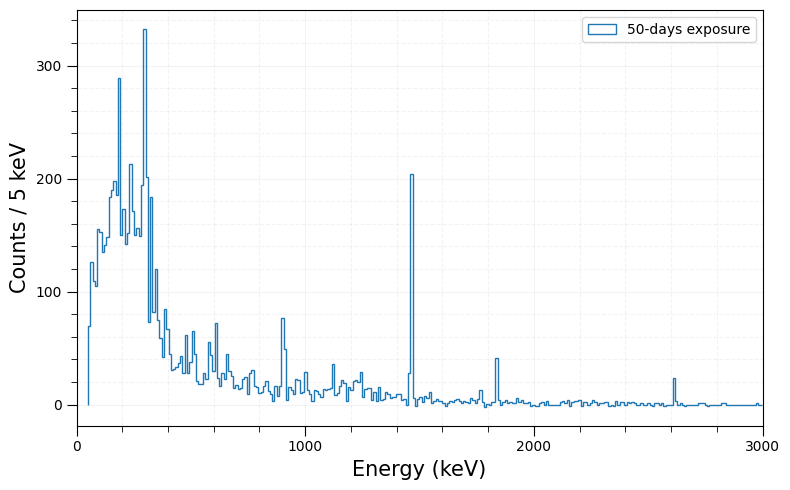

In [30]:
# bkg + 50 days
plt.figure(figsize=(8, 5))
ax = plt.gca()


dx_major = 1000
dx_minor = 200

ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 100
dy_minor = 20

ax.yaxis.set_major_locator(MultipleLocator(dy_major))
ax.yaxis.set_minor_locator(MultipleLocator(dy_minor))

ax.tick_params(axis='x', which='major', length=7, labelsize=10)
ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4)

# Bin width

#bins = np.linspace(min(E_kev), max(E_kev), int(len(E_kev)/56))
bins = np.linspace(min(E_kev), max(E_kev), int(len(E_kev)/28))
counts, bin_edge, _ = plt.hist(E_kev, bins = bins, weights = spec_net, color = 'tab:blue',   histtype='step',label='50-days exposure')


plt.xlabel('Energy (keV)', size = 15)
plt.ylabel(rf'Counts / {db:.0f} keV', size = 15)
plt.xlim(0, 3000)
#plt.yscale('log')
plt.grid(alpha=0.15)
ax.grid(which='major', linestyle='-', alpha=0.15)
ax.grid(which='minor', linestyle='--', alpha=0.15)
plt.tight_layout()
plt.legend()
plt.show()

In [31]:
peaks = {
    "40-K" : 1460.8
}

dx = {
    "40-K" : 4
}

Y = {
     "40-K" : 0.107
}

eff = { 
    "40-K" : 0.18e-1  }

eff_err = {
     "40-K" : 0.34e-2,
}

227.25381332553266

Best fit:
A = 76.007
mu = 1460.857
sigma = 0.981
B = 0.632


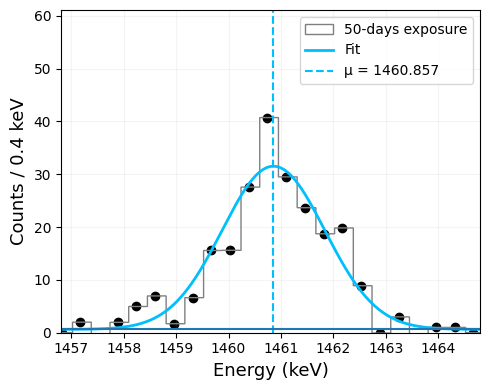

A = 76.007 -5.806/+5.927
mu = 1460.857 -0.070/+0.071
sigma = 0.981 -0.076/+0.075
B = 0.632 -0.345/+0.462


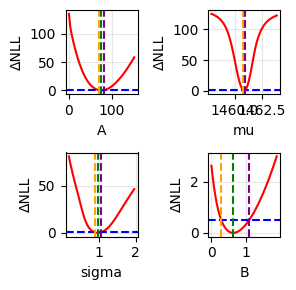

In [32]:

fit_val, fit_err_minus, fit_err_plus, res = fit_gaussian_poisson_plot(
E_kev, spec_net, center=1460.8, de=dx["40-K"] )
    
N, mu_fit, sigma_fit,  B_fit = fit_val
err_N = 0.5*(fit_err_minus[0]+ fit_err_plus[0])

A_40, A_err_40 = compute_A_error(N, err_N , t_50, Y["40-K"], eff["40-K"], eff_err["40-K"], m)





In [33]:
print(f"40K activity : {A_40:.2f}  +/- {A_err_40 : .2f} mBq/kg")

40K activity : 16.75  +/-  3.42 mBq/kg


In [34]:
Aw_mathias = 40
Aw_err_math = 10
Ag_math = 70
Ag_err_math = 20

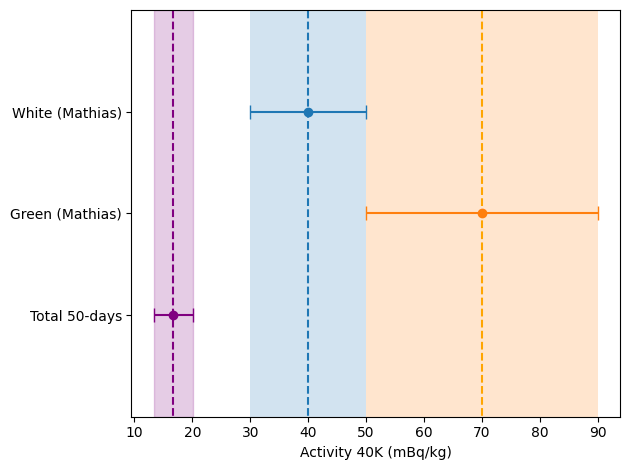

In [35]:
 
plt.figure()

# Bande  di Mathias (White)
plt.fill_betweenx(
    [-1, 3],
    Aw_mathias - Aw_err_math,
    Aw_mathias + Aw_err_math,
    alpha=0.2
)

# Bande ±σ di Mathias (Green)
plt.fill_betweenx(
    [-1, 3],
    Ag_math -  Ag_err_math,
    Ag_math +  Ag_err_math,
    alpha=0.2
)

# Punti Mathias (con errore)
plt.errorbar(Aw_mathias, 2, xerr=Aw_err_math, capsize=5, fmt='o')
plt.vlines(Aw_mathias, -2, 6, ls = '--')
plt.errorbar(Ag_math, 1, xerr=Ag_err_math,capsize=5, fmt='o')
plt.vlines(Ag_math, -2, 6, color= 'orange', ls = '--')
# Tuoi dati

plt.errorbar(A_40, 0, xerr=A_err_40, color = 'purple', capsize=5,fmt='o')


# Bande  di 50 
plt.fill_betweenx(
    [-1, 3],
    A_40 - A_err_40,
    A_40 + A_err_40,
    color = "purple",
    alpha=0.2
)
plt.vlines(A_40, -2, 6, color = 'purple', ls = '--')


plt.yticks(
    [0, 1, 2, ],
    ["Total 50-days", "Green (Mathias)", "White (Mathias)"]
)

plt.xlabel("Activity 40K (mBq/kg)")

plt.ylim(-1, 3)
plt.tight_layout()
plt.show()